In [4]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

# importing the dataset

df = pd.read_csv('ds_salaries.csv')

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [7]:
df.info() # to find out details about the dataset

<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 322.8 KB


In [9]:
df.shape # 3755 raws and 11 columns

(3755, 11)

In [11]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 3755 and your columns are 11


In [13]:
df.isnull()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
3750,False,False,False,False,False,False,False,False,False,False,False
3751,False,False,False,False,False,False,False,False,False,False,False
3752,False,False,False,False,False,False,False,False,False,False,False
3753,False,False,False,False,False,False,False,False,False,False,False


In [14]:
df.isnull().sum() # find out the number of null values in each column

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [50]:
job_counts = df['job_title'].value_counts().reset_index()
job_counts.columns = ['job_title', 'count']

job_counts.head(10)

,job_title,count
0,Data Engineer,1040
1,Data Scientist,840
2,Data Analyst,612
3,Machine Learning Engineer,289
4,Analytics Engineer,103
5,Data Architect,101
6,Research Scientist,82
7,Applied Scientist,58
8,Data Science Manager,58
9,Research Engineer,37


In [51]:
# find out the average salary for each job title
avg_salary_role = df.groupby('job_title')['salary_in_usd'].mean()
avg_salary_role = avg_salary_role.sort_values(ascending=False)

avg_salary_role.head(10)

job_title
Data Science Tech Lead                375000.000000
Cloud Data Architect                  250000.000000
Data Lead                             212500.000000
Data Analytics Lead                   211254.500000
Principal Data Scientist              198171.125000
Director of Data Science              195140.727273
Principal Data Engineer               192500.000000
Machine Learning Software Engineer    192420.000000
Data Science Manager                  191278.775862
Applied Scientist                     190264.482759
Name: salary_in_usd, dtype: float64

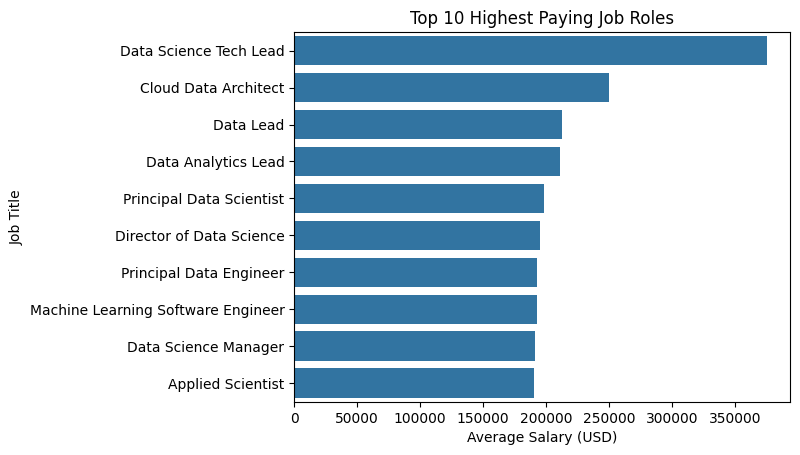

In [47]:
#plt.figure(figsize=(10,5)) # to increase the size of the plot

top_roles = avg_salary_role.head(10)

sns.barplot(x='salary_in_usd',
            y='job_title',
            data=top_roles.reset_index()
            )

plt.title("Top 10 Highest Paying Job Roles")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Title")

plt.show()

In [52]:
avg_salary_country = df.groupby('company_location')['salary_in_usd'].mean()
avg_salary_country = avg_salary_country.sort_values(ascending=False)

avg_salary_country.head(10)

company_location
IL    271446.500000
PR    167500.000000
US    151822.009539
RU    140333.333333
CA    131917.689655
NZ    125000.000000
BA    120000.000000
IE    114943.428571
JP    114127.333333
SE    105000.000000
Name: salary_in_usd, dtype: float64

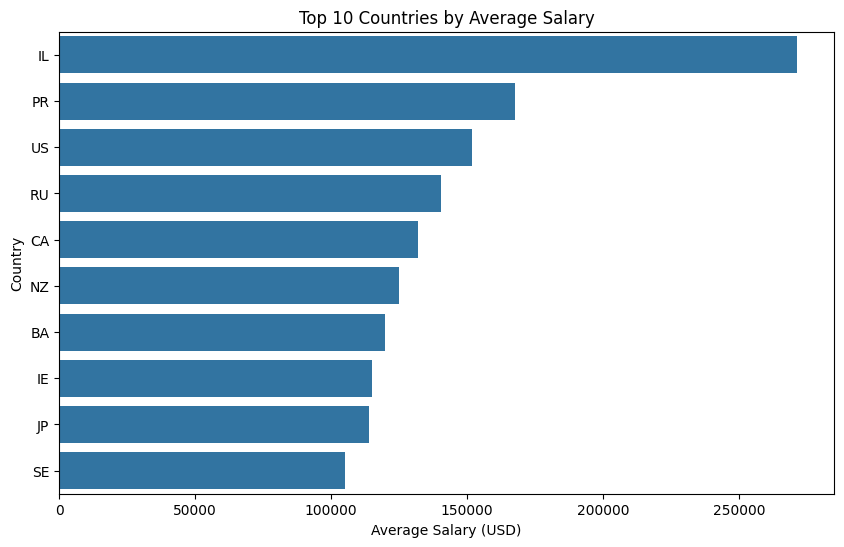

In [54]:
avg_salary_country = avg_salary_country.reset_index()

top_countries = avg_salary_country.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
            x='salary_in_usd',
            y='company_location', 
            data=top_countries
            )

plt.title("Top 10 Countries by Average Salary")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Country")

plt.show()

In [56]:
emp_salary = df.groupby('employment_type')['salary_in_usd'].mean()
emp_salary = emp_salary.sort_values(ascending=False)

print(emp_salary)

employment_type
FT    138314.199570
CT    113446.900000
FL     51807.800000
PT     39533.705882
Name: salary_in_usd, dtype: float64


/var/folders/tz/zkqx8_kd1fvc0gygcsl9s8jw0000gn/T/ipykernel_29907/4259035188.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='employment_type', y='salary_in_usd', data=emp_salary, palette='coolwarm')


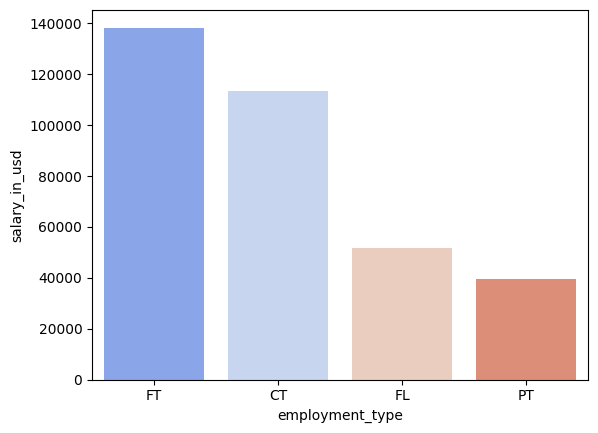

In [82]:
sns.barplot(x='employment_type', y='salary_in_usd', data=emp_salary, palette='coolwarm')
plt.show()


remote_ratio
0      144316.202288
50      78400.687831
100    136481.452830
Name: salary_in_usd, dtype: float64


/var/folders/tz/zkqx8_kd1fvc0gygcsl9s8jw0000gn/T/ipykernel_29907/1206629936.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df, palette='magma')


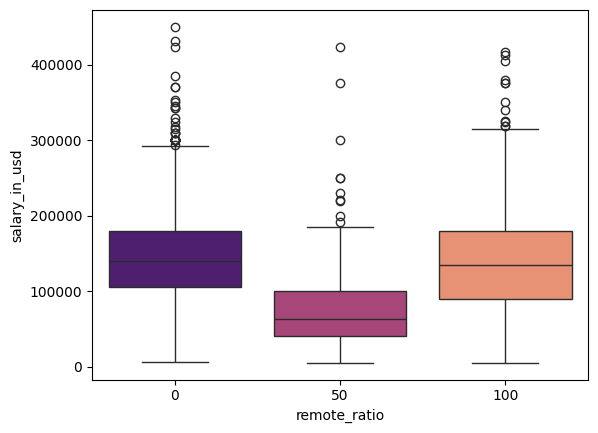

In [83]:
remote_salary = df.groupby('remote_ratio')['salary_in_usd'].mean()
print(remote_salary)

sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df, palette='magma')
plt.show()

/var/folders/tz/zkqx8_kd1fvc0gygcsl9s8jw0000gn/T/ipykernel_29907/2656863.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='company_size', y='salary_in_usd', data=company_salary, palette='Set1')


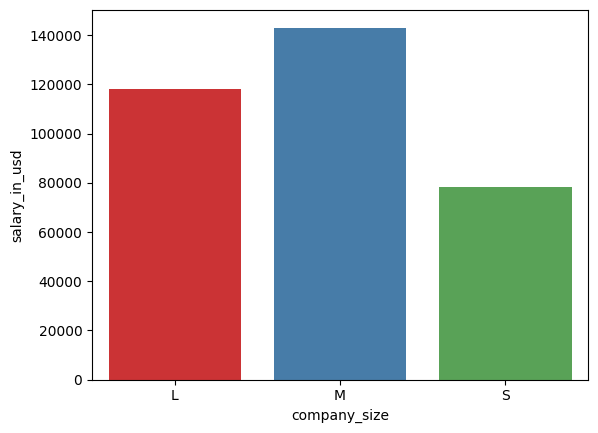

In [87]:
company_salary = df.groupby('company_size')['salary_in_usd'].mean().reset_index()

sns.barplot(x='company_size', y='salary_in_usd', data=company_salary, palette='Set1')
plt.show()

work_year
2020     92302.631579
2021     94087.208696
2022    133338.620793
2023    149045.541176
Name: salary_in_usd, dtype: float64


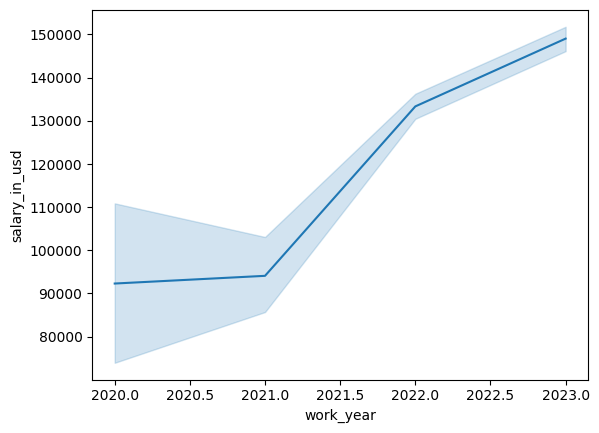

In [80]:
year_salary = df.groupby('work_year')['salary_in_usd'].mean()
print(year_salary)

sns.lineplot(x='work_year', y='salary_in_usd', data=df)
plt.show()

               work_year    salary  salary_in_usd  remote_ratio
work_year       1.000000 -0.094724       0.228290     -0.236430
salary         -0.094724  1.000000      -0.023676      0.028731
salary_in_usd   0.228290 -0.023676       1.000000     -0.064171
remote_ratio   -0.236430  0.028731      -0.064171      1.000000


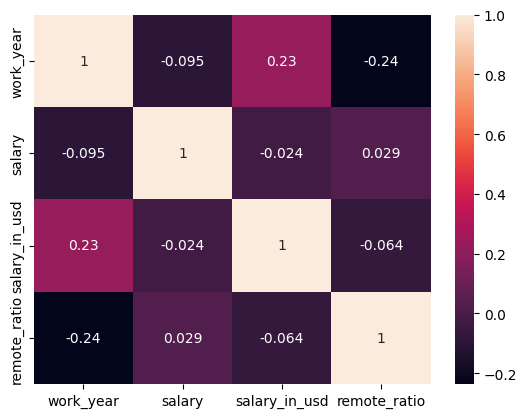

In [84]:
corr = df.corr(numeric_only=True)
print(corr)

sns.heatmap(corr, annot=True)
plt.show()

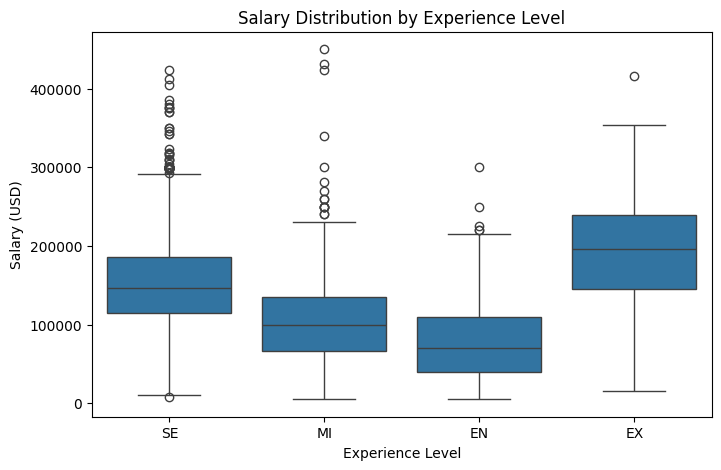

In [92]:
plt.figure(figsize=(8,5))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)
plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")
plt.show()

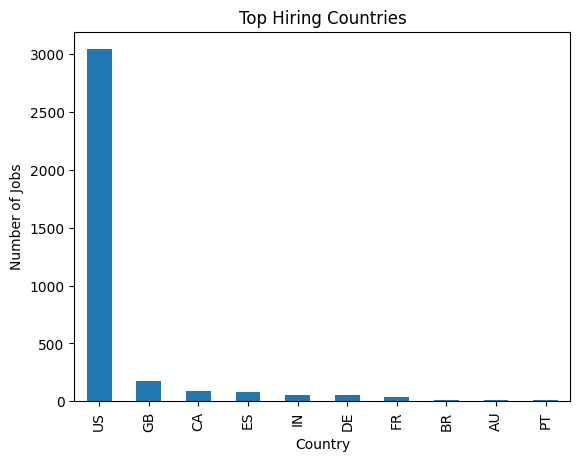

In [94]:
top_countries = df['company_location'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top Hiring Countries")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")
plt.show()

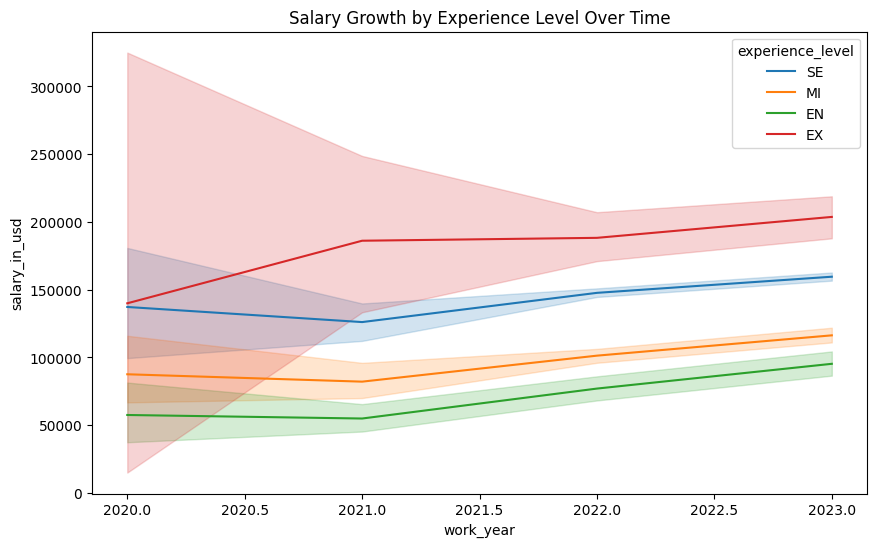

In [95]:
plt.figure(figsize=(10,6))
sns.lineplot(x='work_year', y='salary_in_usd', hue='experience_level', data=df)
plt.title("Salary Growth by Experience Level Over Time")
plt.show()